# 실습 5: 텍스트 탐지 (Text Detection)

## 학습 목표
- Amazon Rekognition의 `detect_text` API로 이미지에서 텍스트를 추출합니다.
- LINE과 WORD 타입의 차이를 이해하고 필터링합니다.

## API 개요
`detect_text`는 이미지에서 텍스트를 감지합니다.
- **반환값**: `response['TextDetections']`
  - `DetectedText`: 탐지된 텍스트 내용
  - `Type`: `'LINE'` (전체 줄) 또는 `'WORD'` (개별 단어)
  - `Confidence`: 신뢰도
  - `Geometry.BoundingBox`: 위치 정보


In [3]:
import boto3
import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ✅ [제공 코드]
rekognition = boto3.client('rekognition', region_name='ap-northeast-2')
IMAGE_DIR = './images/'
image_filename = 'lab05.png'
image_path = os.path.join(IMAGE_DIR, image_filename)

def load_image_bytes(path):
    with open(path, 'rb') as f:
        return f.read()

image_bytes = load_image_bytes(image_path)
print(f"이미지 경로: {image_path}")
print(f"파일 존재 여부: {os.path.exists(image_path)}")

이미지 경로: ./images/lab05.png
파일 존재 여부: True


## ✏️ TODO 1: detect_text API 호출


In [4]:
# ✏️ TODO 1: detect_text API를 호출하세요
response = rekognition.detect_text( # ← API 메서드명
    Image={'Bytes': image_bytes}    # ← 이미지 바이트
)

all_texts = response['TextDetections']
print(f"전체 탐지 텍스트 수: {len(all_texts)}개")

전체 탐지 텍스트 수: 5개


## ✏️ TODO 2: LINE과 WORD 타입 분리 출력

TextDetections에서 Type이 'LINE'인 것만 필터링하여 출력하세요.


In [5]:
# ✏️ TODO 2: LINE 타입만 필터링하여 출력하세요
lines = [t for t in all_texts if t['Type'] == 'LINE']  # ← 'Type', 'LINE'
words = [t for t in all_texts if t['Type'] == 'WORD']  # ← 'Type', 'WORD'

print(f"LINE 수: {len(lines)}개")
print(f"WORD 수: {len(words)}개")

print("\n탐지된 텍스트 줄(LINE):")
print("-" * 50)
for line in lines:
    text = line['DetectedText']  # ← 'DetectedText'
    conf = line['Confidence']  # ← 'Confidence'
    print(f"  [{conf:.1f}%] {text}")

LINE 수: 2개
WORD 수: 3개

탐지된 텍스트 줄(LINE):
--------------------------------------------------
  [98.9%] UNIVERSITY
  [98.7%] SOOKMYUNG WOMEN'S


## ✏️ TODO 3: 텍스트 위치 시각화

LINE 타입의 텍스트 위치를 파란색 사각형으로 표시하세요.


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


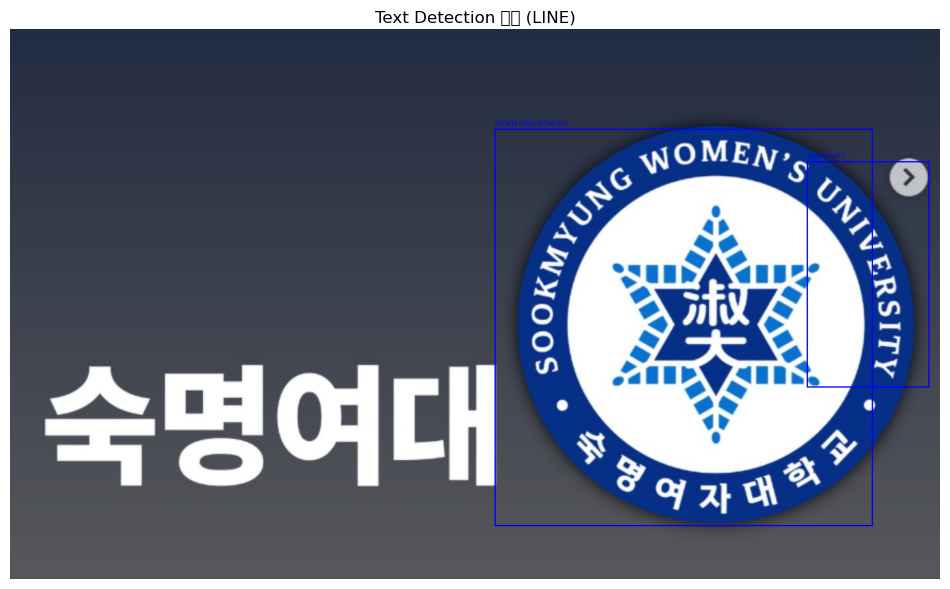

In [6]:
# ✏️ TODO 3: LINE 텍스트의 BoundingBox를 이미지에 표시하세요
img = Image.open(image_path)
draw = ImageDraw.Draw(img)
w, h = img.size

for line in lines:
    box = line['Geometry']['BoundingBox']  # ← 'BoundingBox'
    
    left   = box['Left']  * w
    top    = box['Top']   * h
    right  = left + box['Width']  * w
    bottom = top  + box['Height'] * h
    
    draw.rectangle([left, top, right, bottom], outline='blue', width=2)
    draw.text((left, top - 15), line['DetectedText'][:20], fill='blue')

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Text Detection 결과 (LINE)')
plt.show()

## 💡 심화 도전
1. WORD 타입의 텍스트만 시각화해보고 LINE과 어떻게 다른지 비교해보세요.
2. 탐지된 모든 텍스트를 하나의 문자열로 합쳐 출력해보세요.
3. Confidence가 95% 이하인 텍스트는 빨간색으로, 이상은 파란색으로 구분해 표시해보세요.
